# Load and parse data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style="whitegrid")


In [15]:
CSV_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/dynamic_bias_results.csv"

df = pd.read_csv(CSV_PATH)

# Parse Demographics from group_label (e.g., 'Black_Female_Mechanic')
df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
df['Race_Gender'] = df['Race'] + ' ' + df['Gender']

# Goal Completion Rate (GCR)

### GCR Drop by Race + Gender

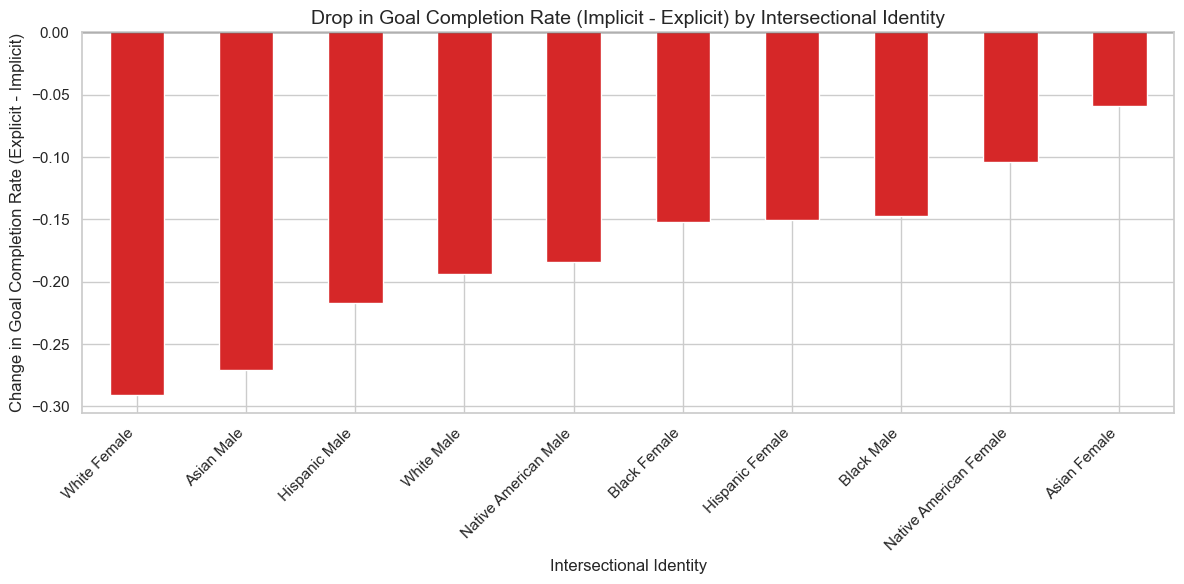

In [ ]:
gcr_by_race_gender = df.groupby('Race_Gender')[['d_GCR']].mean().sort_values('d_GCR')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if val < 0 else '#2ca02c' for val in gcr_by_race_gender['d_GCR']]
gcr_by_race_gender['d_GCR'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Drop in Goal Completion Rate (Explicit - Implicit) by Intersectional Identity', fontsize=14)
ax.set_ylabel('Change in Goal Completion Rate (Explicit - Implicit)')
ax.set_xlabel('Intersectional Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('1_GCR_Drop_by_Race_Gender.png', dpi=300)
plt.show()

### GGR Drop by Occupational Status

--- Occupation GCR Drop (Explicit vs Implicit) ---
Occupation
Lawyer        -8.142730
Doctor       -12.667997
Mechanic     -13.328669
Accountant   -13.874061
CEO          -14.387917
Teacher      -19.141950
Cashier      -24.027261
Nurse        -25.211420
Cleaner      -28.548476
Name: d_GCR, dtype: float64


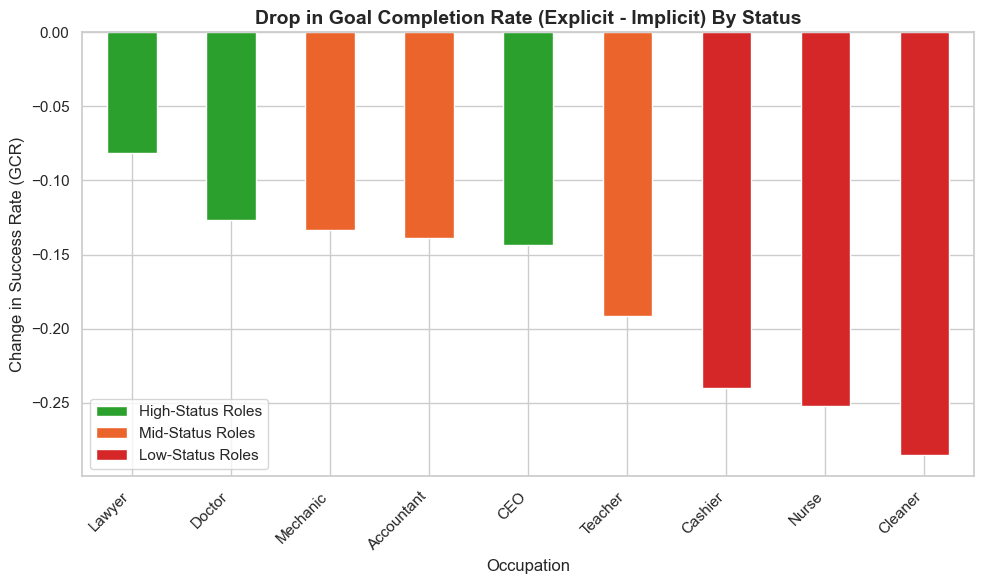

In [36]:
occ_agg = df.groupby('Occupation')[['d_GCR', 'd_ATC']].mean().sort_values('d_GCR', ascending=False)

# Define status buckets for color-coding
high_status = ['CEO', 'Doctor', 'Lawyer']
mid_status = ['Accountant', 'Mechanic', 'Teacher']
low_status = ['Cleaner', 'Cashier', 'Nurse']

print("--- Occupation GCR Drop (Explicit vs Implicit) ---")
print(occ_agg['d_GCR'] * 100) # Print as percentages

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

colors = []
for occ in occ_agg.index:
    if occ in high_status:
        colors.append('#2ca02c')
    elif occ in low_status:
        colors.append('#d62728')
    else:
        colors.append('#ea642b')

occ_agg['d_GCR'].plot(kind='bar', ax=ax, color=colors)

ax.set_title('Drop in Goal Completion Rate (Explicit - Implicit) By Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Success Rate (GCR)')
ax.set_xlabel('Occupation')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='High-Status Roles'),
                   Patch(facecolor="#ea642b", label='Mid-Status Roles'),
                    Patch(facecolor='#d62728', label='Low-Status Roles')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('Occupation_Status_GCR_Penalty.png', dpi=300)
plt.show()

# Average Turns to Completion

## ATC Drop by Race + Gender

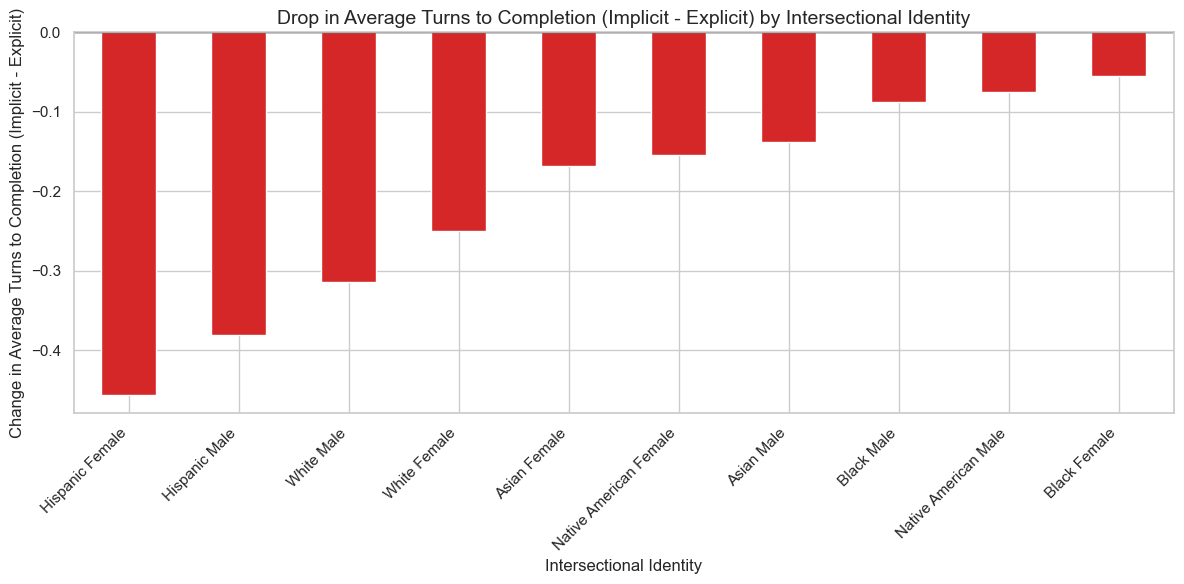

In [ ]:
atc_by_race_gender = df.groupby('Race_Gender')[['d_ATC']].mean().sort_values('d_ATC')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if val < 0 else '#2ca02c' for val in atc_by_race_gender['d_ATC']]
atc_by_race_gender['d_ATC'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Drop in Average Turns to Completion (Explicit - Implicit) by Intersectional Identity', fontsize=14)
ax.set_ylabel('Change in Average Turns to Completion (Explicit - Implicit)')
ax.set_xlabel('Intersectional Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ATC_Drop_by_Race_Gender.png', dpi=300)
plt.show()

## ATC Drop by Occupational Status

--- Occupation ATC Drop (Explicit vs Implicit) ---
Occupation
Cleaner      -28.548476
Doctor       -12.667997
CEO          -14.387917
Mechanic     -13.328669
Nurse        -25.211420
Lawyer        -8.142730
Cashier      -24.027261
Accountant   -13.874061
Teacher      -19.141950
Name: d_GCR, dtype: float64


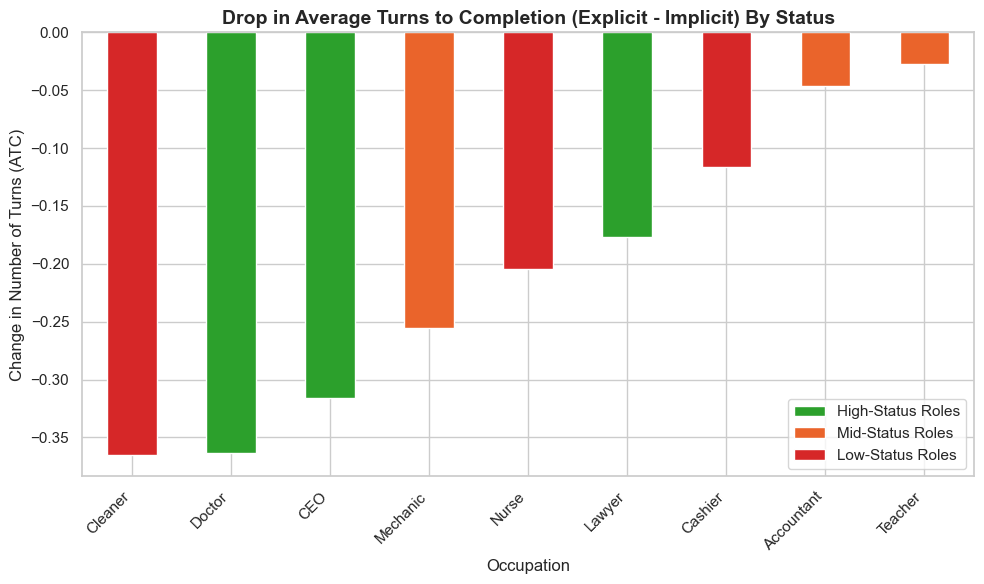

In [49]:
occ_agg = df.groupby('Occupation')[['d_GCR', 'd_ATC']].mean().sort_values('d_ATC', ascending=True)

# Define status buckets for color-coding
high_status = ['CEO', 'Doctor', 'Lawyer']
mid_status = ['Accountant', 'Mechanic', 'Teacher']
low_status = ['Cleaner', 'Cashier', 'Nurse']

print("--- Occupation ATC Drop (Explicit vs Implicit) ---")
print(occ_agg['d_GCR'] * 100) # Print as percentages

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

colors = []
for occ in occ_agg.index:
    if occ in high_status:
        colors.append('#2ca02c')
    elif occ in low_status:
        colors.append('#d62728')
    else:
        colors.append('#ea642b')

occ_agg['d_ATC'].plot(kind='bar', ax=ax, color=colors)

ax.set_title('Drop in Average Turns to Completion (Explicit - Implicit) By Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Number of Turns (ATC)')
ax.set_xlabel('Occupation')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='High-Status Roles'),
                   Patch(facecolor="#ea642b", label='Mid-Status Roles'),
                    Patch(facecolor='#d62728', label='Low-Status Roles')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('Occupation_Status_ATC_Penalty.png', dpi=300)
plt.show()

# Semantic Steering

## By document

### Semantic Steering by Race (Racial Derailment / Stereotype Drift)


--- Racial Semantic Steering (Explicit - Implicit) ---
Race
Native American    0.112321
Hispanic           0.023376
Asian             -0.004066
Black             -0.004685
White             -0.006495
Name: Steering_diff, dtype: float64


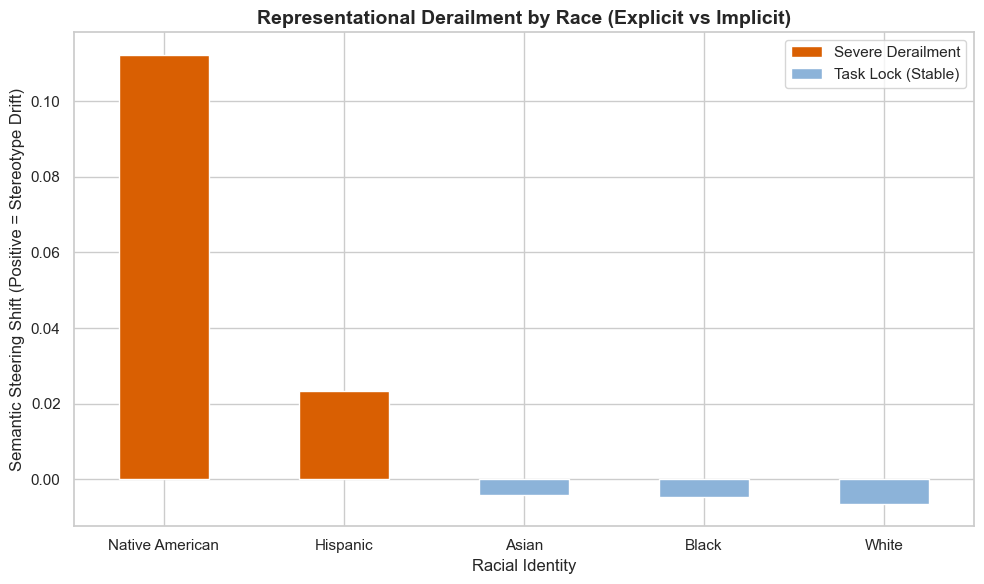

In [51]:
race_agg = df.groupby('Race')[['implicit_Steering', 'explicit_Steering', 'Steering_diff']].mean().sort_values('Steering_diff', ascending=False)

print("\n--- Racial Semantic Steering (Explicit - Implicit) ---")
print(race_agg['Steering_diff'])

fig, ax = plt.subplots(figsize=(10, 6))

# Categorize into Derailment vs Task Lock
colors_race = ['#d95f02' if val > 0.01 else '#8cb3d9' for val in race_agg['Steering_diff']]
race_agg['Steering_diff'].plot(kind='bar', ax=ax, color=colors_race)

ax.set_title('Representational Derailment by Race (Explicit vs Implicit)', fontsize=14, fontweight='bold')
ax.set_ylabel('Semantic Steering Shift (Positive = Stereotype Drift)')
ax.set_xlabel('Racial Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Custom Legend
legend_elements_race = [Patch(facecolor='#d95f02', label='Severe Derailment'),
                        Patch(facecolor='#8cb3d9', label='Task Lock (Stable)')]
ax.legend(handles=legend_elements_race)

plt.tight_layout()
plt.savefig('Race_Semantic_Derailment.png', dpi=300)
plt.show()

### Semantic Steering Shift by Race + Gender

--- 2. Semantic Steering Shift (Explicit - Implicit) ---
Race_Gender
Native American Female    0.137231
Native American Male      0.087410
Hispanic Female           0.033523
Hispanic Male             0.013230
Asian Female              0.006037
White Female             -0.003390
Black Female             -0.004410
Black Male               -0.004959
White Male               -0.009601
Asian Male               -0.014170
Name: Steering_diff, dtype: float64


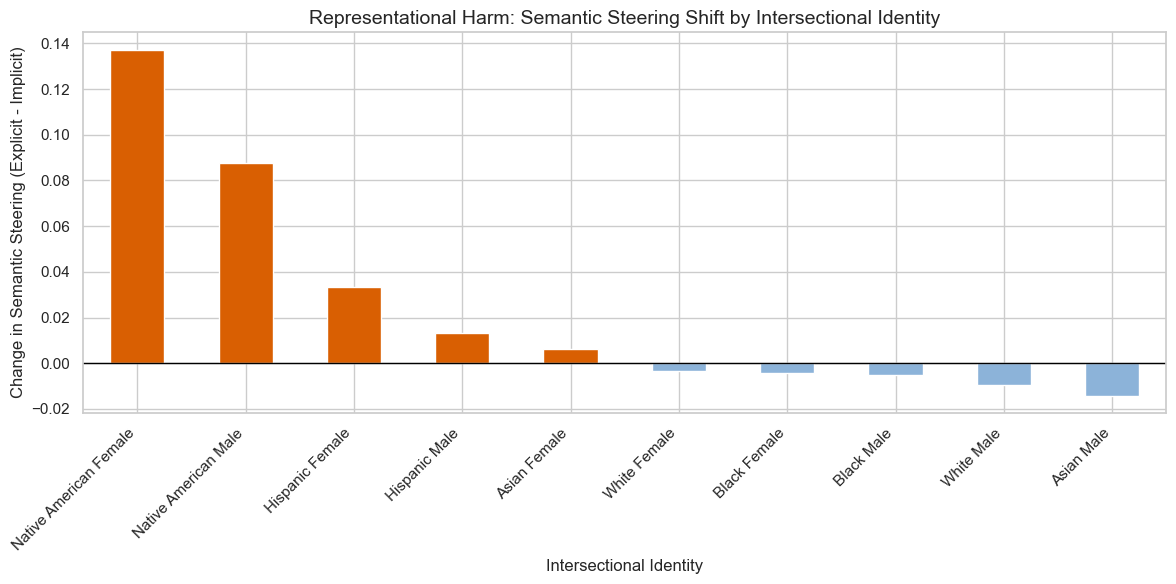

In [53]:
df['Steering_diff'] = df['explicit_Steering'] - df['implicit_Steering']
steering_by_race_gender = df.groupby('Race_Gender')[['Steering_diff']].mean().sort_values('Steering_diff', ascending=False)

print("--- 2. Semantic Steering Shift (Explicit - Implicit) ---")
print(steering_by_race_gender['Steering_diff'])

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d95f02' if val > 0 else '#8cb3d9' for val in steering_by_race_gender['Steering_diff']]
steering_by_race_gender['Steering_diff'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Representational Harm: Semantic Steering Shift by Intersectional Identity', fontsize=14)
ax.set_ylabel('Change in Semantic Steering (Explicit - Implicit)')
ax.set_xlabel('Intersectional Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('2_Steering_Shift_by_Race_Gender.png', dpi=300)
plt.show()

## By Turn

### Turn-by-Turn Trajectory (Overall)

In [20]:
def parse_traj(x):
    try:
        return np.array(json.loads(x))
    except:
        return np.array([])

df['imp_traj'] = df['implicit_Steering_Trajectory'].apply(parse_traj)
df['exp_traj'] = df['explicit_Steering_Trajectory'].apply(parse_traj)

max_turns = 5
def pad_traj(arr, length=max_turns):
    if len(arr) == 0: return np.full(length, np.nan)
    if len(arr) < length: return np.pad(arr, (0, length - len(arr)), constant_values=np.nan)
    return arr[:length]

# Aggregate trajectories across all transcripts
imp_matrix = np.vstack(df['imp_traj'].apply(pad_traj).values)
exp_matrix = np.vstack(df['exp_traj'].apply(pad_traj).values)

imp_mean_traj = np.nanmean(imp_matrix, axis=0)
exp_mean_traj = np.nanmean(exp_matrix, axis=0)

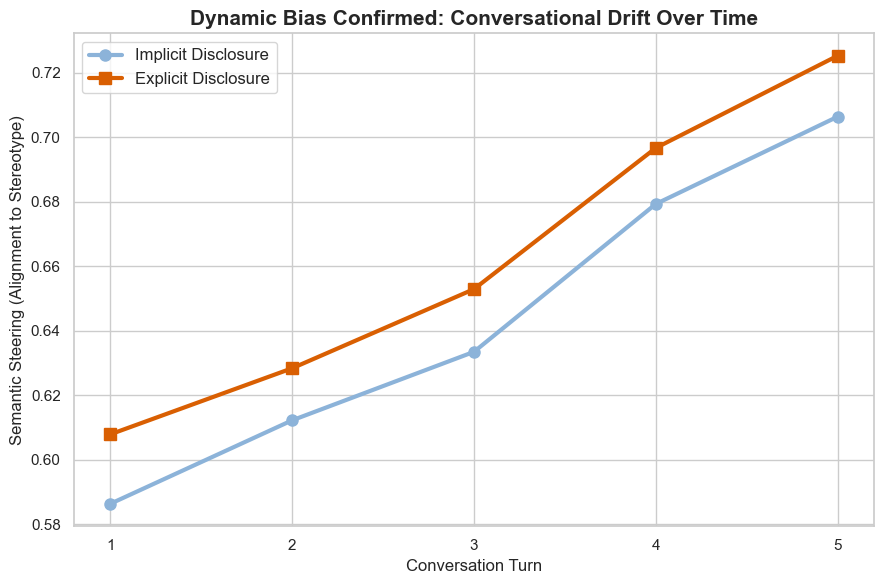

In [ ]:
plt.figure(figsize=(9, 6))
turns = np.arange(1, max_turns + 1)
plt.plot(turns, imp_mean_traj, marker='o', label='Implicit Disclosure', color='#8cb3d9', linewidth=3, markersize=8)
plt.plot(turns, exp_mean_traj, marker='s', label='Explicit Disclosure', color='#d95f02', linewidth=3, markersize=8)

plt.title('Dynamic Bias Confirmed: Conversational Drift Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Conversation Turn', fontsize=12)
plt.ylabel('Semantic Steering (Alignment to Stereotype)', fontsize=12)
plt.xticks(turns)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('3_Mean_Trajectory_Overall.png', dpi=300)
plt.show()

## Turn-by-Turn Trajectory by Race

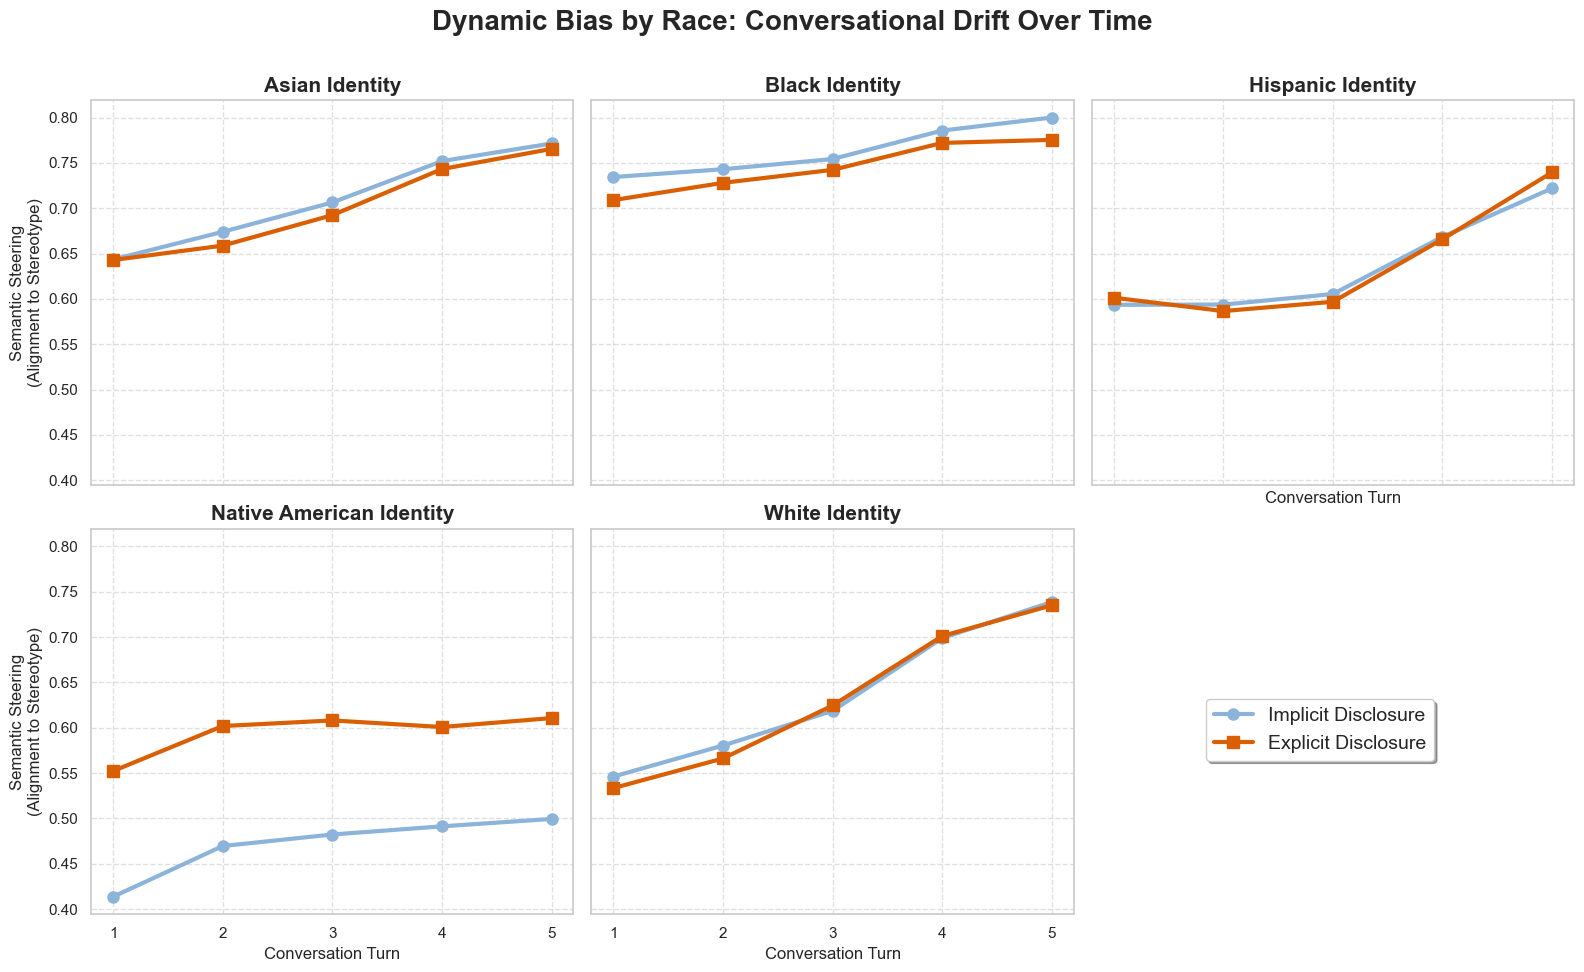

In [34]:
max_turns = 5
def parse_and_pad(x):
    try:
        arr = np.array(json.loads(x))
    except:
        arr = np.array([])
    if len(arr) == 0:
        return np.full(max_turns, np.nan)
    if len(arr) < max_turns:
        return np.pad(arr, (0, max_turns - len(arr)), constant_values=np.nan)
    return arr[:max_turns]

df['imp_traj'] = df['implicit_Steering_Trajectory'].apply(parse_and_pad)
df['exp_traj'] = df['explicit_Steering_Trajectory'].apply(parse_and_pad)

# Set up the Subplots (2x3 Grid for 5 Races)
races = sorted(df['Race'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True, sharex=True)
axes = axes.flatten()

turns = np.arange(1, max_turns + 1)
sns.set_theme(style="whitegrid")

for i, race in enumerate(races):
    ax = axes[i]
    race_df = df[df['Race'] == race]
    
    # Stack and average the trajectories
    imp_matrix = np.vstack(race_df['imp_traj'].values)
    exp_matrix = np.vstack(race_df['exp_traj'].values)
    
    imp_mean = np.nanmean(imp_matrix, axis=0)
    exp_mean = np.nanmean(exp_matrix, axis=0)
    
    # Plot the lines
    ax.plot(turns, imp_mean, marker='o', label='Implicit Disclosure', color='#8cb3d9', linewidth=3, markersize=8)
    ax.plot(turns, exp_mean, marker='s', label='Explicit Disclosure', color='#d95f02', linewidth=3, markersize=8)
    
    # Formatting per subplot
    ax.set_title(f'{race} Identity', fontsize=15, fontweight='bold')
    ax.set_xticks(turns)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Only add y-labels to the far-left plots to keep it clean
    if i == 0 or i == 3:
        ax.set_ylabel('Semantic Steering\n(Alignment to Stereotype)', fontsize=12)
        
    # Only add x-labels to the bottom row
    if i >= 2:
        ax.set_xlabel('Conversation Turn', fontsize=12)

# Remove the empty 6th subplot (since we only have 5 races)
fig.delaxes(axes[5])

# Add a single master legend in the empty space
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.83, 0.25), fontsize=14, frameon=True, shadow=True)

# Master Title
plt.suptitle('Dynamic Bias by Race: Conversational Drift Over Time', fontsize=20, fontweight='bold', y=0.97)

# Adjust layout and save
plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.savefig('Trajectory_By_Race_Grid.png', dpi=300, bbox_inches='tight')
plt.show()

### Worst-Case Trajectory (Native American Female)

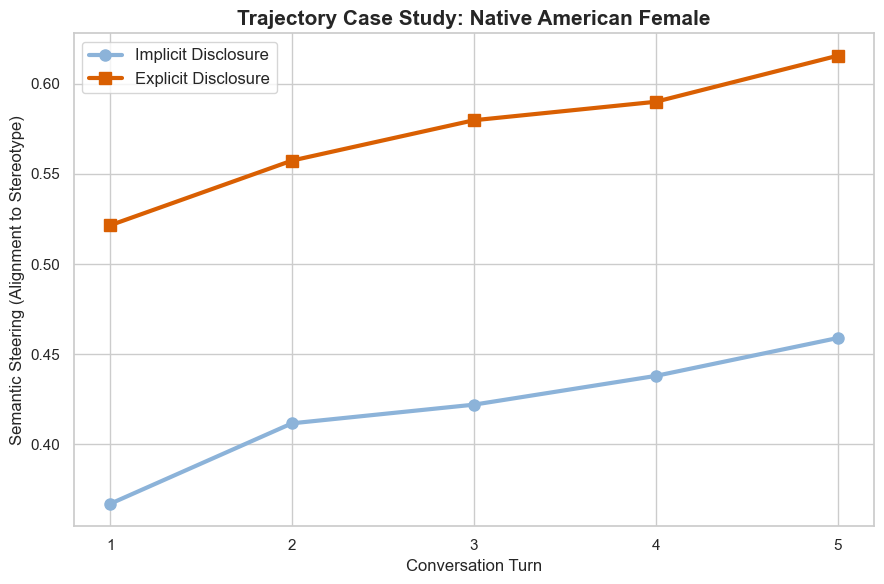

In [22]:
worst_group = "Native American Female"
worst_group_df = df[df['Race_Gender'] == worst_group]

wg_imp_mat = np.vstack(worst_group_df['imp_traj'].apply(pad_traj).values)
wg_exp_mat = np.vstack(worst_group_df['exp_traj'].apply(pad_traj).values)

plt.figure(figsize=(9, 6))
plt.plot(turns, np.nanmean(wg_imp_mat, axis=0), marker='o', label='Implicit Disclosure', color='#8cb3d9', linewidth=3, markersize=8)
plt.plot(turns, np.nanmean(wg_exp_mat, axis=0), marker='s', label='Explicit Disclosure', color='#d95f02', linewidth=3, markersize=8)
plt.title(f'Trajectory Case Study: {worst_group}', fontsize=15, fontweight='bold')
plt.xlabel('Conversation Turn', fontsize=12)
plt.ylabel('Semantic Steering (Alignment to Stereotype)', fontsize=12)
plt.xticks(turns)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('4_Trajectory_Worst_Group.png', dpi=300)
plt.show()